# Hardware

In [14]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os


data_path = Path(r"C:\Users\Daniel K\Desktop\DAKI\3. Semester\P3\Nvidia_Jetson_p3\inference_data")

In [15]:

#hw_files = sorted(f for f in data_path.glob("*.csv") if not f.stem.endswith("_lat"))
# Get CSV files, ignore *_lat files, and filter by second-to-last character
hw_files = sorted(f for f in data_path.glob("*.csv") if not f.stem.endswith("_lat") and f.stem[-2] == "1")


# Extract model names (everything before the first '_')
model_names = [f.stem.split("_")[0] for f in hw_files]


# Create a dictionary mapping model name → file
data = {}
for f in hw_files:
    model = f.stem.split("_")[0]  # name before first _
    df = pd.read_csv(f)
    # Convert absolute timestamp → relative time
    df["time_s"] = df["ts"] - df["ts"].iloc[0]
    df = df.set_index("time_s")
    data[model] = df


# Smoothing parameters
TIME_WINDOW = "10s"
variables = [
    "gpu", "cpu1", "cpu2", "cpu3", "cpu4",
    "ram", "temp_gpu", "temp_cpu", "power"
]



# Prepare colors for models
models = sorted(data.keys())
colors = plt.cm.tab20(range(len(models)))  # more distinct colors
color_map = dict(zip(models, colors))



# Compute smoothed variables
for model, df in data.items():
    for var in variables:
        if var in df.columns:
            df.index = pd.to_timedelta(df.index, unit='s')  # convert seconds to timedelta
            df[f"{var}_smooth"] = df[var].rolling(TIME_WINDOW).mean()
    data[model] = df


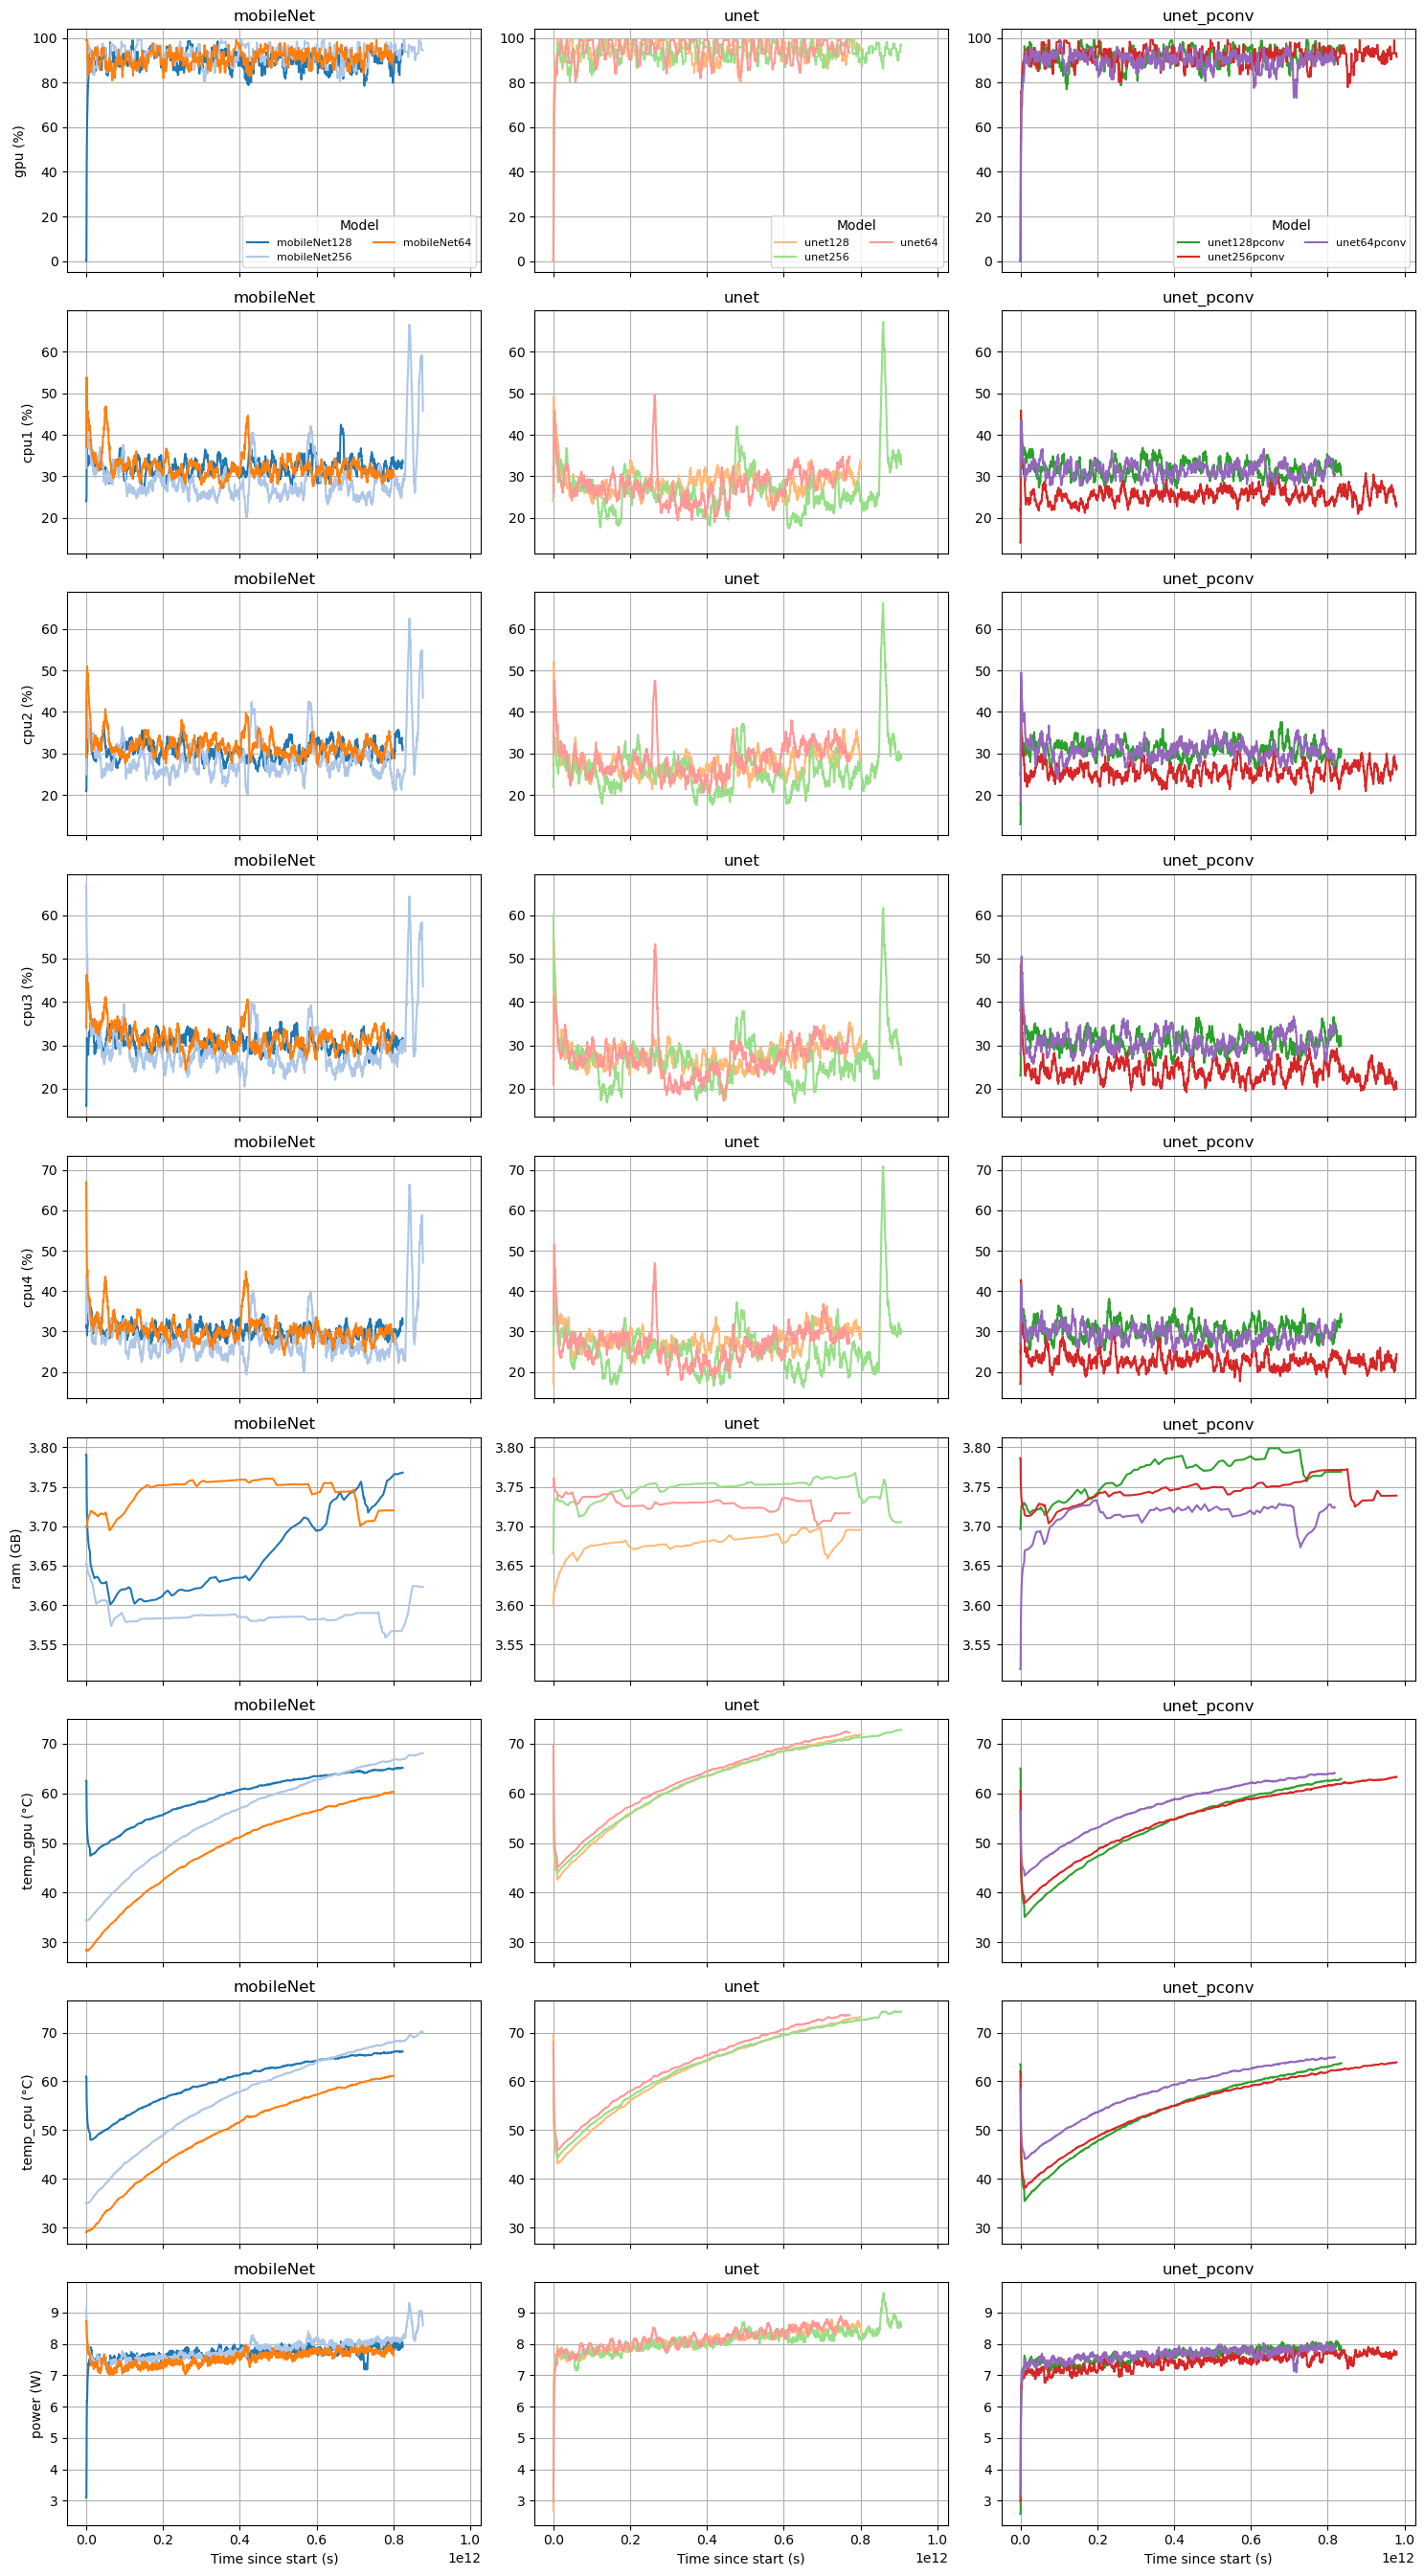

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Units for y-axis
units = {
    "gpu": "%",
    "cpu1": "%",
    "cpu2": "%",
    "cpu3": "%",
    "cpu4": "%",
    "ram": "GB",
    "temp_gpu": "°C",
    "temp_cpu": "°C",
    "power": "W"
}

variables = ["gpu", "cpu1", "cpu2", "cpu3", "cpu4", "ram", "temp_gpu", "temp_cpu", "power"]
groups = {
    "mobileNet": [m for m in data.keys() if m.startswith("mobileNet")],
    "unet": [m for m in data.keys() if m.startswith("unet") and "pconv" not in m],
    "unet_pconv": [m for m in data.keys() if "pconv" in m]
}

colors = plt.cm.tab20(range(len(data)))
color_map = dict(zip(data.keys(), colors))

n_vars = len(variables)
n_groups = len(groups)
fig, axes = plt.subplots(n_vars, n_groups, figsize=(5*n_groups, 3*n_vars), sharex=True)

# Precompute y-limits per variable
y_limits = {}
for var in variables:
    all_values = []
    for model in data:
        df = data[model]
        if f"{var}_smooth" in df.columns:
            all_values.extend(df[f"{var}_smooth"].values)
    if all_values:  # only if there is data
        min_val = np.min(all_values)
        max_val = np.max(all_values)
        margin = (max_val - min_val) * 0.05  # 5% margin
        y_limits[var] = (min_val - margin, max_val + margin)
    else:
        y_limits[var] = (0, 1)  # fallback

# Plot
for i, var in enumerate(variables):
    for j, (group_name, model_list) in enumerate(groups.items()):
        ax = axes[i, j] if n_vars > 1 else axes[j]  # handle single variable edge case
        for model in model_list:
            df = data[model]
            if f"{var}_smooth" in df.columns:
                ax.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=1.5)
        ax.set_ylim(y_limits[var])  # enforce consistent y-axis per variable
        if i == n_vars - 1:
            ax.set_xlabel("Time since start (s)")
        if j == 0:
            ax.set_ylabel(f"{var} ({units.get(var, '')})")
        ax.set_title(group_name)
        ax.grid(True)

# Legends
for j, (group_name, model_list) in enumerate(groups.items()):
    axes[0, j].legend(title="Model", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


In [17]:
# Compute smoothed variables, including CPU average
for model, df in data.items():
    df.index = pd.to_timedelta(df.index, unit='s')  # convert seconds to timedelta
    
    # 1️⃣ Compute CPU average
    df["cpu"] = df[["cpu1", "cpu2", "cpu3", "cpu4"]].mean(axis=1)
    
    # 2️⃣ Smooth CPU average
    df["cpu_smooth"] = df["cpu"].rolling(TIME_WINDOW).mean()
    
    # 3️⃣ Smooth other variables
    for var in ["gpu", "ram", "temp_gpu", "temp_cpu", "power"]:
        if var in df.columns:
            df[f"{var}_smooth"] = df[var].rolling(TIME_WINDOW).mean()
    
    data[model] = df


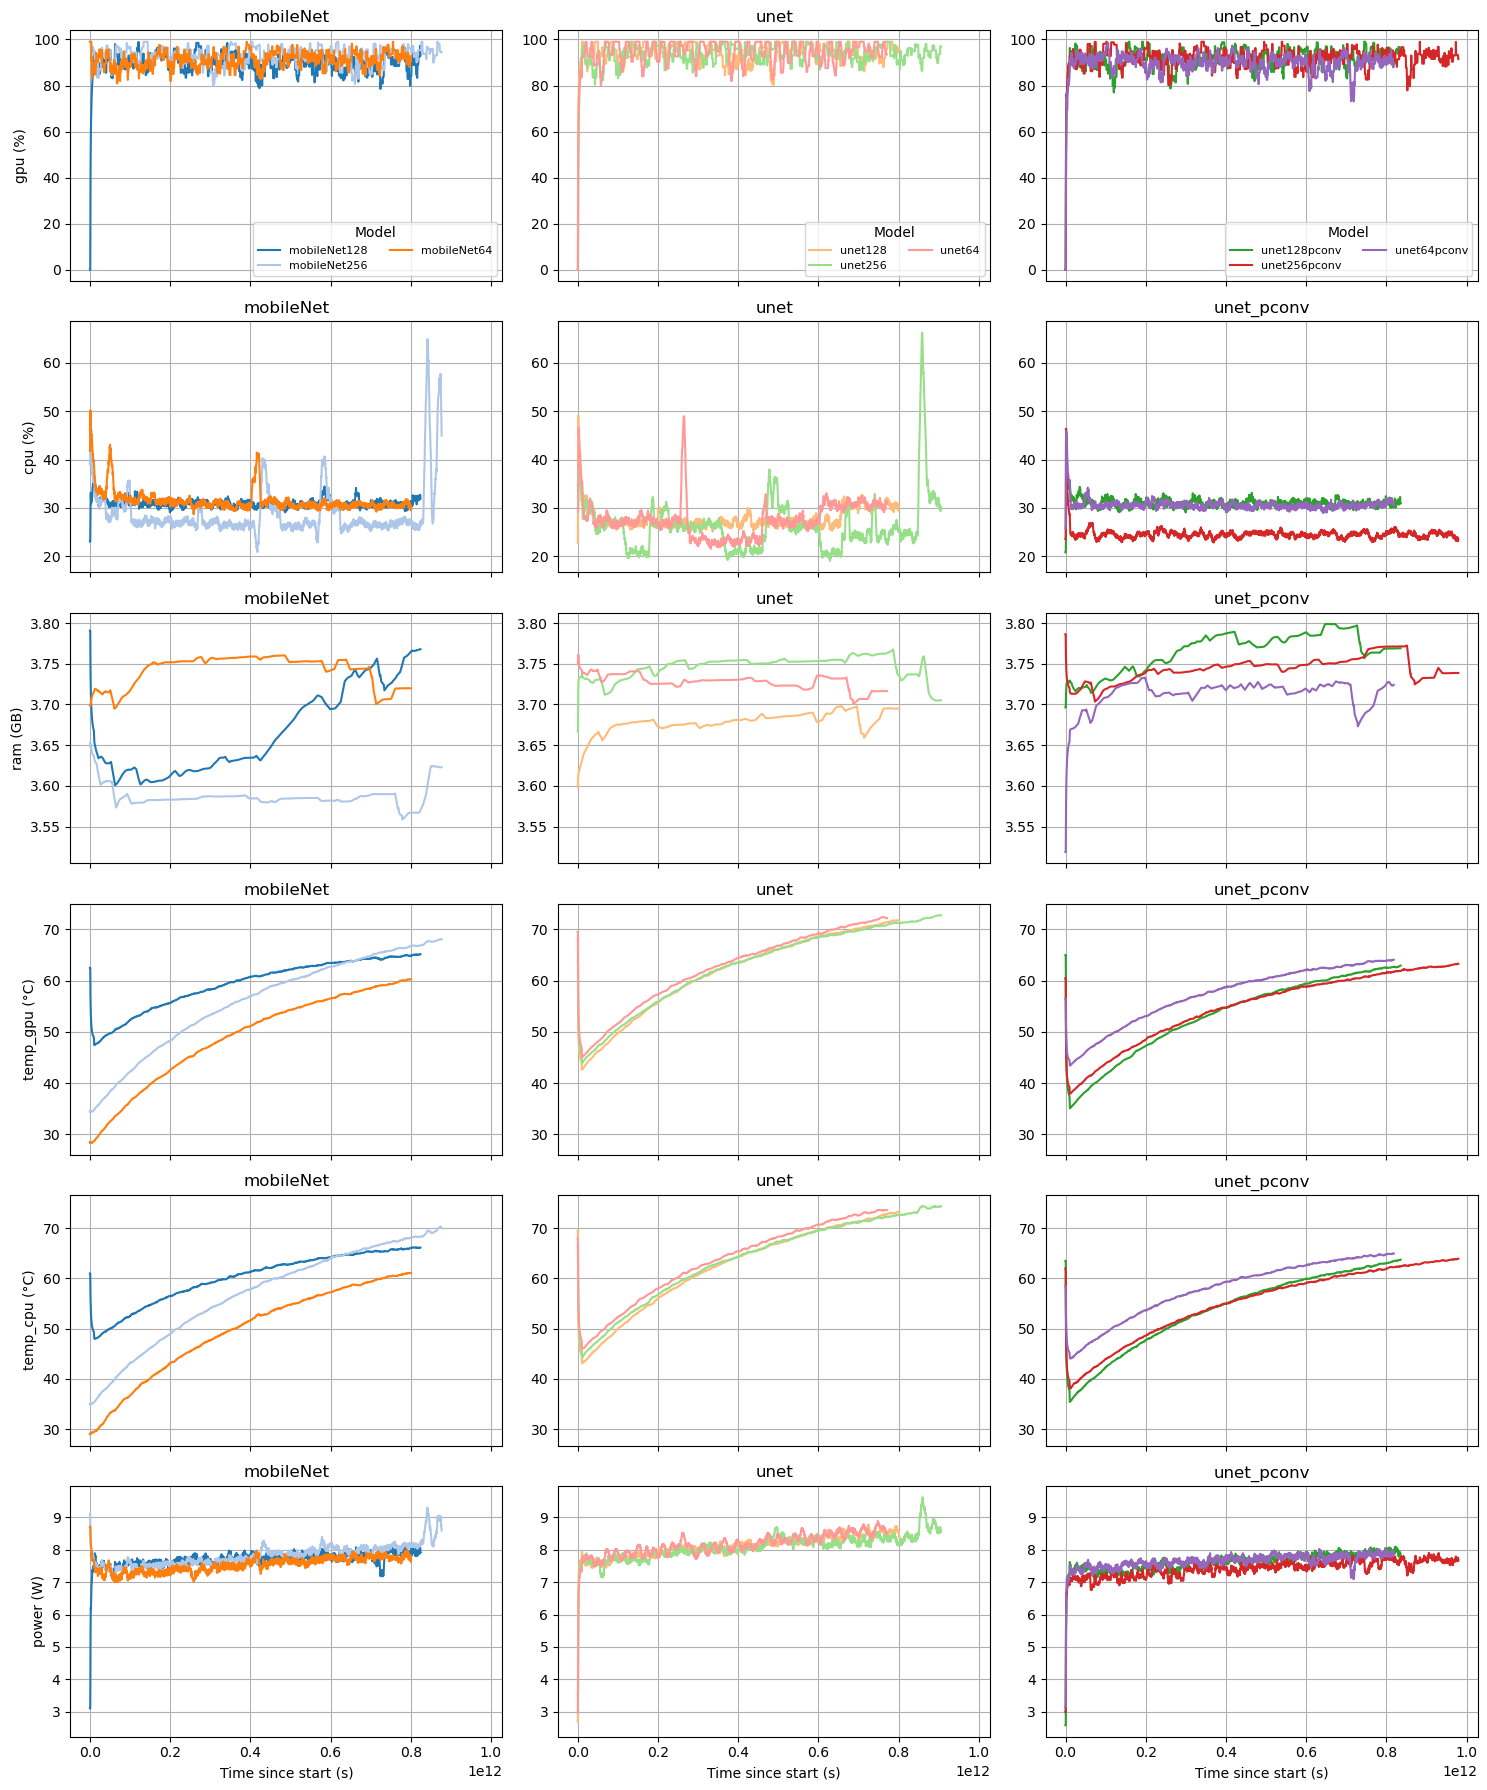

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Units for y-axis
units = {
    "gpu": "%",
    "cpu": "%",
    "ram": "GB",
    "temp_gpu": "°C",
    "temp_cpu": "°C",
    "power": "W"
}

# Variables to plot (combine cpu1-4 into "cpu")
variables = ["gpu", "cpu", "ram", "temp_gpu", "temp_cpu", "power"]

groups = {
    "mobileNet": [m for m in data.keys() if m.startswith("mobileNet")],
    "unet": [m for m in data.keys() if m.startswith("unet") and "pconv" not in m],
    "unet_pconv": [m for m in data.keys() if "pconv" in m]
}

colors = plt.cm.tab20(range(len(data)))
color_map = dict(zip(data.keys(), colors))

n_vars = len(variables)
n_groups = len(groups)
fig, axes = plt.subplots(n_vars, n_groups, figsize=(5*n_groups, 3*n_vars), sharex=True)

# Precompute y-limits per variable
y_limits = {}
for var in variables:
    all_values = []
    for model in data:
        df = data[model].copy()
        if var == "cpu":
            # average cpu1-4
            df[var] = df[["cpu1", "cpu2", "cpu3", "cpu4"]].mean(axis=1)
        if f"{var}_smooth" in df.columns:
            all_values.extend(df[f"{var}_smooth"].values)
        elif var in df.columns:
            all_values.extend(df[var].values)
    if all_values:  # only if there is data
        min_val = np.min(all_values)
        max_val = np.max(all_values)
        margin = (max_val - min_val) * 0.05  # 5% margin
        y_limits[var] = (min_val - margin, max_val + margin)
    else:
        y_limits[var] = (0, 1)  # fallback

# Plot
for i, var in enumerate(variables):
    for j, (group_name, model_list) in enumerate(groups.items()):
        ax = axes[i, j] if n_vars > 1 else axes[j]  # handle single variable edge case
        for model in model_list:
            df = data[model].copy()
            # compute average if CPU
            if var == "cpu":
                df[var] = df[["cpu1", "cpu2", "cpu3", "cpu4"]].mean(axis=1)
            # use smooth column if available
            plot_col = f"{var}_smooth" if f"{var}_smooth" in df.columns else var
            ax.plot(df.index, df[plot_col], label=model, color=color_map[model], linewidth=1.5)
        ax.set_ylim(y_limits[var])  # enforce consistent y-axis per variable
        if i == n_vars - 1:
            ax.set_xlabel("Time since start (s)")
        if j == 0:
            ax.set_ylabel(f"{var} ({units.get(var, '')})")
        ax.set_title(group_name)
        ax.grid(True)

# Legends
for j, (group_name, model_list) in enumerate(groups.items()):
    axes[0, j].legend(title="Model", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


# Latency